In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import joblib
import os
from pathlib import Path

# Thư mục outputs (pipeline mới)
OUTPUTS_DIR = Path("../outputs")
FIG_DIR = OUTPUTS_DIR / "figures"
MODEL_DIR = OUTPUTS_DIR / "models"
METRICS_DIR = OUTPUTS_DIR / "metrics"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Đã nạp xong thư viện và cấu hình thư mục outputs/.")

✅ Đã nạp xong thư viện và cấu hình thư mục outputs/.


In [2]:
# 1) Load model (ưu tiên best_model.pkl từ outputs/)
best_model_path = MODEL_DIR / "best_model.pkl"
if best_model_path.exists():
    model_path = best_model_path
else:
    # fallback: model cũ trong artifacts (nếu có)
    model_path = Path("../artifacts/models/xgboost_best_model.pkl")

loaded_model = joblib.load(model_path)
print(f"✅ Đã tải mô hình thành công từ: {model_path}")

# 2) Load X_test, y_test (ưu tiên từ outputs/metrics)
# Tự động tìm file mới nhất theo prefix
x_candidates = sorted(METRICS_DIR.glob("X_test_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)
y_candidates = sorted(METRICS_DIR.glob("y_test_*.csv"), key=lambda p: p.stat().st_mtime, reverse=True)

if x_candidates and y_candidates:
    X_test = pd.read_csv(x_candidates[0])
    y_test = pd.read_csv(y_candidates[0])["is_return"]
    print(f"✅ Đã nạp X_test/y_test từ outputs: {x_candidates[0].name}, {y_candidates[0].name}")
else:
    print("⚠️ Chưa thấy X_test/y_test trong outputs/metrics. Sẽ load từ module src (nếu có).")

✅ Đã tải mô hình thành công từ: ..\outputs\models\best_model.pkl
✅ Đã nạp X_test/y_test từ outputs: X_test_20260317-154109.csv, y_test_20260317-154109.csv


In [3]:
import sys
import os

# Nếu chưa load được X_test/y_test từ outputs thì mới fallback sang src
if "X_test" not in globals() or "y_test" not in globals():
    sys.path.append(os.path.abspath('..'))
    from src.models.models import RetailReturnModeler

    modeler = RetailReturnModeler()
    X_train, X_test, y_train, y_test = modeler.load_and_split_data()

    print("✅ Đã nạp thành công X_test và y_test từ module src!")

In [4]:
# Dự đoán nhãn (0: Không trả hàng, 1: Có trả hàng)
y_pred = loaded_model.predict(X_test)

# Dự đoán xác suất (Dùng để vẽ các biểu đồ nâng cao như ROC-AUC nếu cần)
y_pred_proba = loaded_model.predict_proba(X_test)[:, 1] 

print("✅ Đã hoàn tất dự đoán trên tập Test.")

✅ Đã hoàn tất dự đoán trên tập Test.


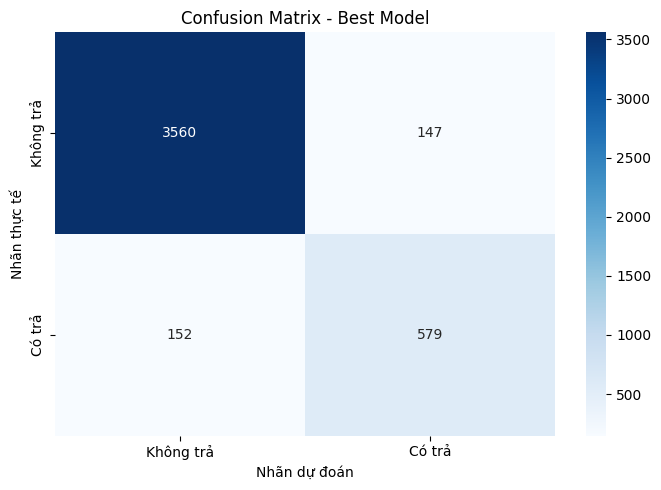

✅ Đã lưu Confusion Matrix: ..\outputs\figures\confusion_matrix_best_model.png


In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Không trả', 'Có trả'],
    yticklabels=['Không trả', 'Có trả'],
)
plt.title('Confusion Matrix - Best Model')
plt.ylabel('Nhãn thực tế')
plt.xlabel('Nhãn dự đoán')
plt.tight_layout()

out_path = FIG_DIR / 'confusion_matrix_best_model.png'
plt.savefig(out_path, dpi=150)
plt.show()
print(f"✅ Đã lưu Confusion Matrix: {out_path}")

In [6]:
# In báo cáo đánh giá chi tiết
print("BÁO CÁO HIỆU SUẤT MÔ HÌNH (XGBoost):")
print("-" * 50)
print(classification_report(y_test, y_pred, target_names=['Không trả', 'Có trả']))

BÁO CÁO HIỆU SUẤT MÔ HÌNH (XGBoost):
--------------------------------------------------
              precision    recall  f1-score   support

   Không trả       0.96      0.96      0.96      3707
      Có trả       0.80      0.79      0.79       731

    accuracy                           0.93      4438
   macro avg       0.88      0.88      0.88      4438
weighted avg       0.93      0.93      0.93      4438



In [7]:
# Phân tích lỗi: False Positive / False Negative theo phân khúc
import numpy as np

# Nếu X_test là numpy array thì chuyển về DataFrame
if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test)
else:
    X_test_df = X_test.copy()

# Chuẩn hóa index
X_test_df = X_test_df.reset_index(drop=True)
y_test_s = pd.Series(y_test).reset_index(drop=True)
y_pred_s = pd.Series(y_pred).reset_index(drop=True)

fp_mask = (y_test_s == 0) & (y_pred_s == 1)
fn_mask = (y_test_s == 1) & (y_pred_s == 0)

print("FP count:", int(fp_mask.sum()), "FN count:", int(fn_mask.sum()))

# Tạo bins theo quantile cho vài feature numeric (nếu tồn tại)
num_cols = [c for c in X_test_df.columns if np.issubdtype(X_test_df[c].dtype, np.number)]
num_cols = num_cols[:6]  # giới hạn cho gọn

error_profiles = []
for col in num_cols:
    try:
        bins = pd.qcut(X_test_df[col], q=4, duplicates='drop')
        tmp = pd.DataFrame({
            'feature': col,
            'bin': bins.astype(str),
            'count': X_test_df.groupby(bins).size().values,
            'fp_rate': fp_mask.groupby(bins).mean().values,
            'fn_rate': fn_mask.groupby(bins).mean().values,
        })
        error_profiles.append(tmp)
    except Exception:
        continue

if error_profiles:
    prof_df = pd.concat(error_profiles, ignore_index=True)
    display(prof_df.sort_values(['feature','bin']))
else:
    print("Không đủ feature numeric để phân tích theo bins.")

# Nếu có Country (hoặc onehot Country_), phân tích FP/FN theo Country
country_cols = [c for c in X_test_df.columns if 'Country' in str(c)]
if 'Country' in X_test_df.columns:
    seg = X_test_df['Country'].astype(str)
    seg_df = pd.DataFrame({
        'segment': seg,
        'n': seg.value_counts(),
    })
    seg_df['fp_rate'] = fp_mask.groupby(seg).mean()
    seg_df['fn_rate'] = fn_mask.groupby(seg).mean()
    seg_df = seg_df.fillna(0).sort_values('fn_rate', ascending=False)
    print("=== FP/FN theo Country ===")
    display(seg_df.head(15))
else:
    # Nếu đã one-hot, lấy top country có FN cao bằng cách cộng group theo cột
    onehot_countries = [c for c in country_cols if str(c).startswith('Country_')]
    if onehot_countries:
        rows = []
        for c in onehot_countries:
            seg_mask = X_test_df[c] == 1
            if seg_mask.sum() < 20:
                continue
            rows.append({
                'segment': c.replace('Country_',''),
                'n': int(seg_mask.sum()),
                'fp_rate': float(fp_mask[seg_mask].mean()),
                'fn_rate': float(fn_mask[seg_mask].mean()),
            })
        if rows:
            seg_df = pd.DataFrame(rows).sort_values('fn_rate', ascending=False)
            print("=== FP/FN theo Country (one-hot) ===")
            display(seg_df.head(15))


FP count: 147 FN count: 152
Không đủ feature numeric để phân tích theo bins.
=== FP/FN theo Country (one-hot) ===


C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_7900\453772963.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'count': X_test_df.groupby(bins).size().values,
C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_7900\453772963.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  'fp_rate': fp_mask.groupby(bins).mean().values,
C:\Users\NGOC KIEN\AppData\Local\Temp\ipykernel_7900\453772963.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sile

,segment,n,fp_rate,fn_rate
4,Spain,20,0.000000,0.100000
3,Germany,116,0.051724,0.043103
6,United Kingdom,3979,0.031164,0.034933
2,France,96,0.072917,0.010417
0,Belgium,26,0.000000,0.000000
1,EIRE,63,0.047619,0.000000
5,Switzerland,20,0.050000,0.000000


## 5 Actionable Insights để giảm tỉ lệ hoàn hàng

1. **Thiết lập luồng “Review thủ công” cho nhóm rủi ro cao**
   - Dựa trên mô hình, ưu tiên kiểm tra các đơn có xác suất trả hàng cao (ví dụ top 5–10%).
   - Hành động: gọi xác nhận, bổ sung tư vấn, hoặc yêu cầu xác nhận thông tin trước khi xuất kho.

2. **Giảm False Negative bằng cách tối ưu ngưỡng quyết định (threshold tuning)**
   - Nếu doanh nghiệp ưu tiên “không bỏ sót” đơn sẽ trả hàng (FN), nên hạ ngưỡng dự đoán để tăng recall lớp trả hàng.
   - Hành động: chọn threshold theo PR curve/chi phí hoàn hàng thay vì mặc định 0.5.

3. **Cải thiện nội dung sản phẩm cho nhóm sản phẩm có return rate cao**
   - Với các sản phẩm/nhóm sản phẩm thường xuất hiện trong các luật kết hợp hoặc có return rate cao, cần tối ưu mô tả, hình ảnh, hướng dẫn sử dụng, thông số.
   - Hành động: cập nhật ảnh thực tế, thêm video, nêu rõ size/màu/chất liệu, bổ sung FAQ.

4. **Thiết kế chính sách đổi trả theo phân khúc khách hàng (customer segment policy)**
   - Từ phân cụm (RFM + return_rate), xác định nhóm “Return-prone” và nhóm “VIP”.
   - Hành động: 
     - VIP: ưu tiên trải nghiệm, giao nhanh, hỗ trợ đổi trả linh hoạt.
     - Return-prone: tăng mức tư vấn trước mua, giới hạn khuyến mại cho một số SKU rủi ro, hoặc áp dụng kiểm tra bổ sung.

5. **Can thiệp vận hành ở giai đoạn đóng gói – giao hàng để giảm trả do lỗi trải nghiệm**
   - Một phần trả hàng đến từ lỗi đóng gói, thiếu hàng, hư hỏng, giao sai.
   - Hành động: checklist đóng gói theo SKU, quét barcode 2 bước, tăng kiểm tra chất lượng cho nhóm SKU rủi ro, theo dõi tỷ lệ trả theo kho/nhà vận chuyển.
